In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [206]:
df = pd.read_csv("dataset.csv")

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Age                      270000 non-null  int64  
 2   Sex                      270000 non-null  int64  
 3   Chest pain type          270000 non-null  int64  
 4   BP                       270000 non-null  int64  
 5   Cholesterol              270000 non-null  int64  
 6   FBS over 120             270000 non-null  int64  
 7   EKG results              270000 non-null  int64  
 8   Max HR                   270000 non-null  int64  
 9   Exercise angina          270000 non-null  int64  
 10  ST depression            270000 non-null  float64
 11  Slope of ST              270000 non-null  int64  
 12  Number of vessels fluro  270000 non-null  int64  
 13  Thallium                 270000 non-null  int64  
dtypes: f

In [208]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
dtype: int64

In [209]:
df.dtypes

id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

In [210]:
categories_cols = ["Sex", "Chest pain type", "FBS over 120", "EKG results", "Exercise angina", "Slope of ST", "Thallium"]

In [211]:
df = pd.get_dummies(df, columns = categories_cols, drop_first = True)

In [212]:
df.dtypes

id                           int64
Age                          int64
BP                           int64
Cholesterol                  int64
Max HR                       int64
ST depression              float64
Number of vessels fluro      int64
Sex_1                         bool
Chest pain type_2             bool
Chest pain type_3             bool
Chest pain type_4             bool
FBS over 120_1                bool
EKG results_1                 bool
EKG results_2                 bool
Exercise angina_1             bool
Slope of ST_2                 bool
Slope of ST_3                 bool
Thallium_6                    bool
Thallium_7                    bool
dtype: object

In [213]:
X = df.drop("id", axis = 1)
X = X.astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)  
X_pca = pca.fit_transform(X_scaled)

In [214]:
kmeans = KMeans(n_clusters = 2, random_state = 42)
labels = (X_pca[:, 0] > 0).astype(int)
df['cluster'] = labels
df.groupby('cluster').mean()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764998.362015,52.494445,130.670618,242.342795,160.461805,0.295427,0.118421,0.560943,0.197078,0.515266,0.215113,0.068863,0.002592,0.370402,0.074969,0.192039,0.012158,0.011561,0.115857
1,765000.805849,56.070963,130.422519,248.146389,143.973116,1.203082,0.840798,0.894605,0.028944,0.077175,0.879731,0.092892,0.001678,0.623295,0.503798,0.658792,0.039705,0.023869,0.708821


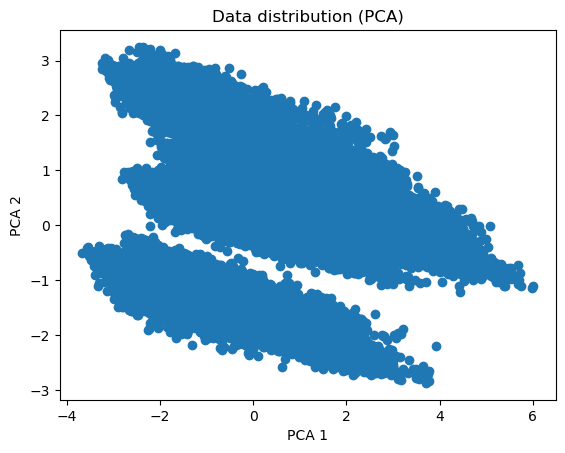

In [215]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Data distribution (PCA)')
plt.show()

In [216]:
df.groupby('cluster').mean()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764998.362015,52.494445,130.670618,242.342795,160.461805,0.295427,0.118421,0.560943,0.197078,0.515266,0.215113,0.068863,0.002592,0.370402,0.074969,0.192039,0.012158,0.011561,0.115857
1,765000.805849,56.070963,130.422519,248.146389,143.973116,1.203082,0.840798,0.894605,0.028944,0.077175,0.879731,0.092892,0.001678,0.623295,0.503798,0.658792,0.039705,0.023869,0.708821


In [217]:
df.groupby('cluster').median()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,764992.0,52.0,130.0,239.0,162.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,765013.0,57.0,130.0,246.0,146.0,1.2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0


In [218]:
df.groupby('cluster').std()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,77928.108287,8.291426,15.21662,33.926587,14.786726,0.560208,0.392904,0.496274,0.397793,0.499769,0.410902,0.253221,0.050849,0.482914,0.263342,0.393905,0.109589,0.106901,0.320054
1,77959.172424,7.786881,14.76372,33.158110,19.790161,1.061730,0.960623,0.307063,0.167649,0.266870,0.325277,0.290282,0.040932,0.484562,0.499988,0.474117,0.195266,0.152642,0.454307


In [219]:
df.groupby('cluster').var()

,id,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Sex_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,FBS over 120_1,EKG results_1,EKG results_2,Exercise angina_1,Slope of ST_2,Slope of ST_3,Thallium_6,Thallium_7
cluster,,,,,,,,,,,,,,,,,,,
0,6.072790e+09,68.747753,231.545528,1151.013286,218.647262,0.313833,0.154373,0.246288,0.158239,0.249769,0.168841,0.064121,0.002586,0.233206,0.069349,0.155161,0.012010,0.011428,0.102435
1,6.077633e+09,60.635516,217.967429,1099.460245,391.650471,1.127270,0.922796,0.094288,0.028106,0.071220,0.105805,0.084264,0.001675,0.234800,0.249988,0.224787,0.038129,0.023300,0.206395


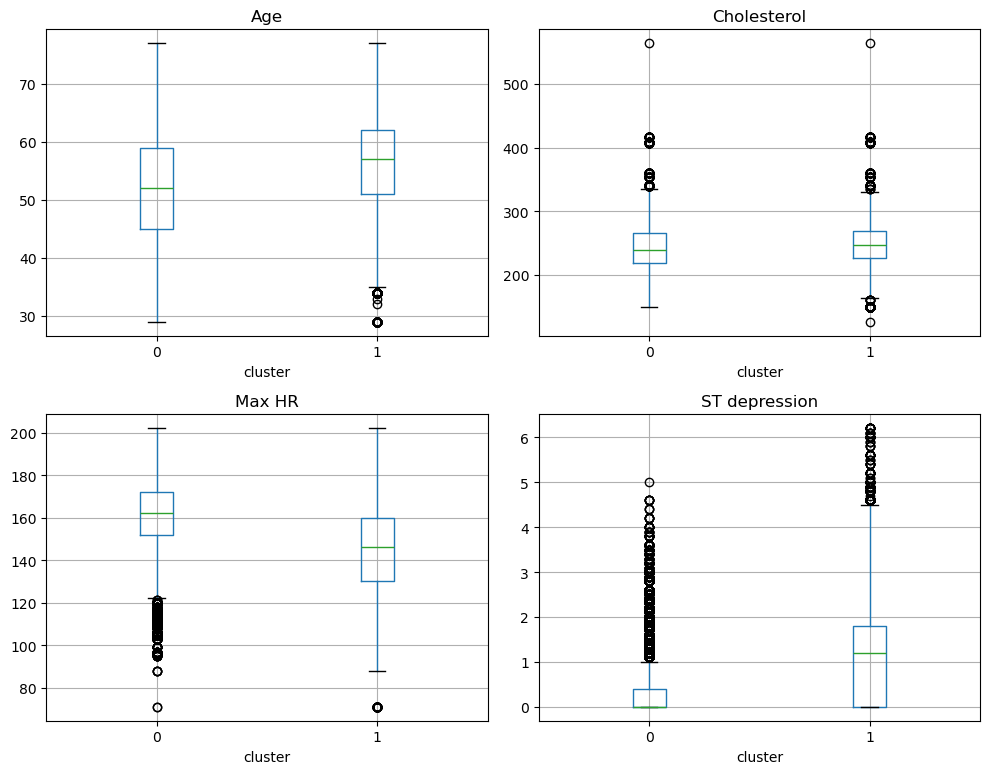

In [220]:
features = ['Age', 'Cholesterol', 'Max HR', 'ST depression']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, col in enumerate(features):
    row = i // 2
    col_idx = i % 2
    
    df.boxplot(column=col, by='cluster', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)

plt.suptitle('') 
plt.tight_layout()
plt.show()

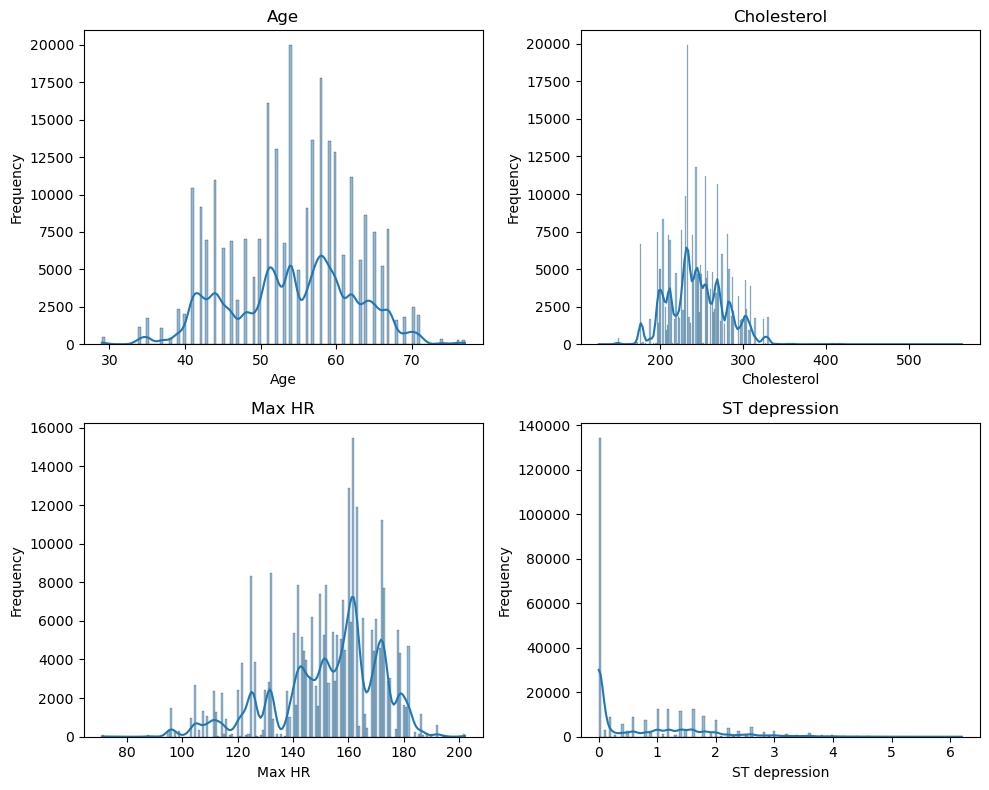

In [221]:
features = ['Age', 'Cholesterol', 'Max HR', 'ST depression']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(features):
    row = i // 2
    col_idx = i % 2
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_ylabel("Frequency")
    
plt.tight_layout()
plt.show()

In [222]:
X = df.drop(['cluster'], axis=1)
y = df['cluster']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [223]:
print(model.score(X_test, y_test))

0.9892222222222222


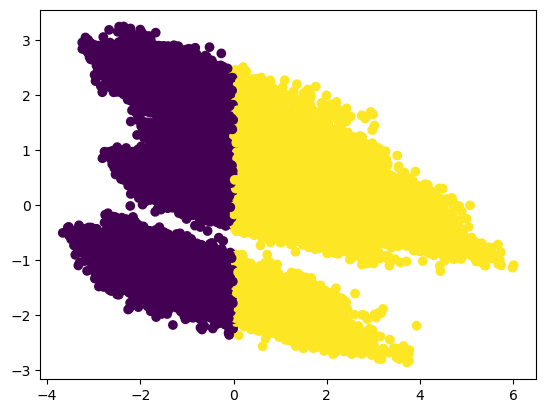

In [250]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])

In [258]:
df.groupby('cluster').mean().T
(df.groupby('cluster').mean().T[1] - df.groupby('cluster').mean().T[0]).sort_values()

Max HR                    -16.488689
Chest pain type_3          -0.438091
BP                         -0.248099
Chest pain type_2          -0.168134
EKG results_1              -0.000914
Thallium_6                  0.012308
FBS over 120_1              0.024029
Slope of ST_3               0.027548
EKG results_2               0.252893
Sex_1                       0.333661
Exercise angina_1           0.428829
Slope of ST_2               0.466754
Thallium_7                  0.592965
Chest pain type_4           0.664618
Number of vessels fluro     0.722377
ST depression               0.907655
id                          2.443834
Age                         3.576519
Cholesterol                 5.803594
dtype: float64

In [256]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

Chest pain type_4          0.203359
Thallium_7                 0.184096
ST depression              0.098643
Exercise angina_1          0.091634
Slope of ST_2              0.085028
Max HR                     0.066947
Chest pain type_3          0.064454
Number of vessels fluro    0.061507
Sex_1                      0.038598
Age                        0.023330
dtype: float64